# 05d — Model D Training: Stacking Meta-Model

Combines race-level predictions from Models A, B, C into a single ensemble.
Uses out-of-fold (OOF) predictions as meta-features to prevent leakage.
CV: LeaveOneSeasonOut (test season = 2023, last season with OOF from all models).

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb

from f1_predictor.features.splits import LeaveOneSeasonOut

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

TRAINING_DIR = Path("data/training")
MODEL_DIR = Path("data/raw/model")

In [3]:
def wrap_imputer(model):
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model)])

NAN_TOLERANT_D = {"XGBoost_shallow", "LightGBM_shallow"}

def cv_evaluate(model, X, y, splitter, groups):
    fold_rmse, fold_mae = [], []
    for train_idx, val_idx in splitter.split(groups):
        import sklearn.base
        m = sklearn.base.clone(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = m.predict(X.iloc[val_idx])
        fold_rmse.append(np.sqrt(mean_squared_error(y.iloc[val_idx], preds)))
        fold_mae.append(mean_absolute_error(y.iloc[val_idx], preds))
    return {
        "fold_rmse": fold_rmse, "fold_mae": fold_mae,
        "mean_rmse": np.mean(fold_rmse), "std_rmse": np.std(fold_rmse),
        "mean_mae": np.mean(fold_mae),
    }

## 1. Load OOF Predictions from Models A, B, C

We load the **best** model's validation (OOF) predictions from each.
For Models A and B (lap-level), we aggregate to race level using the last lap.

In [4]:
def find_best_model(model_type):
    """Find the best model for a type by reading test parquets and picking lowest RMSE."""
    import glob
    test_files = sorted(TRAINING_DIR.glob(f"model_{model_type}_*_Test.parquet"))
    best_name, best_rmse = None, float("inf")
    for f in test_files:
        df_t = pd.read_parquet(f)
        rmse = np.sqrt(mean_squared_error(df_t["y_true"], df_t["y_pred"]))
        name = f.stem.replace(f"model_{model_type}_", "").replace("_Test", "")
        if rmse < best_rmse:
            best_rmse = rmse
            best_name = name
    print(f"Best Model {model_type}: {best_name} (test RMSE={best_rmse:.4f})")
    return best_name

best_A = find_best_model("A")
best_B = find_best_model("B")
best_C = find_best_model("C")

Best Model A: LightGBM_Deep (test RMSE=2.7121)
Best Model B: LightGBM_DART (test RMSE=5.2849)
Best Model C: RandomForest (test RMSE=4.1921)


In [5]:
def aggregate_lap_to_race(val_df):
    """Aggregate lap-level predictions to race level using the last lap per driver-race."""
    val_df = val_df.sort_values(["season", "round", "driver_abbrev", "lap_number"])
    last_laps = val_df.groupby(["season", "round", "driver_abbrev"]).tail(1)
    return last_laps[["season", "round", "driver_abbrev", "y_true", "y_pred"]].copy()

# Load OOF validation predictions
val_A = pd.read_parquet(TRAINING_DIR / f"model_A_{best_A}_Validation.parquet")
val_B = pd.read_parquet(TRAINING_DIR / f"model_B_{best_B}_Validation.parquet")
val_C = pd.read_parquet(TRAINING_DIR / f"model_C_{best_C}_Validation.parquet")

# Aggregate A and B to race level
race_A = aggregate_lap_to_race(val_A).rename(columns={"y_pred": "pred_A", "y_true": "true_A"})
race_B = aggregate_lap_to_race(val_B).rename(columns={"y_pred": "pred_B", "y_true": "true_B"})
race_C = val_C.rename(columns={"y_pred": "pred_C", "y_true": "true_C"})

print(f"Race-level A: {race_A.shape}")
print(f"Race-level B: {race_B.shape}")
print(f"Race-level C: {race_C.shape}")

Race-level A: (2015, 5)
Race-level B: (2035, 5)
Race-level C: (2077, 7)


## 2. Build Meta-Feature Matrix

In [6]:
merge_key = ["season", "round", "driver_abbrev"]
meta = race_C[merge_key + ["pred_C", "true_C"]].copy()

# Merge A predictions (OOF covers 2019-2023)
meta = meta.merge(race_A[merge_key + ["pred_A"]], on=merge_key, how="left")
# Merge B predictions
meta = meta.merge(race_B[merge_key + ["pred_B"]], on=merge_key, how="left")

# Target is the race-level finish position from Model C's ground truth
meta["finish_position"] = meta["true_C"]
meta = meta.dropna(subset=["finish_position"])

print(f"Meta-feature matrix: {meta.shape}")
print(f"Seasons: {sorted(meta['season'].unique())}")
print(f"NaN counts:\n{meta[['pred_A', 'pred_B', 'pred_C']].isna().sum()}")
meta.head()

Meta-feature matrix: (2077, 8)
Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
NaN counts:
pred_A    62
pred_B    42
pred_C     0
dtype: int64


,season,round,driver_abbrev,pred_C,true_C,pred_A,pred_B,finish_position
0,2019,1,ALB,13.350049,14.0,13.053401,12.862641,14.0
1,2019,1,BOT,4.763563,1.0,0.739778,1.221309,1.0
2,2019,1,GAS,13.200072,11.0,10.549379,11.051960,11.0
3,2019,1,GIO,12.693463,15.0,13.002591,12.506333,15.0
4,2019,1,GRO,9.881163,18.0,13.367078,12.955532,18.0


In [7]:
FEATURE_COLS = ["pred_A", "pred_B", "pred_C"]
TARGET = "finish_position"
ID_COLS = ["season", "round", "driver_abbrev"]

X = meta[FEATURE_COLS]
y = meta[TARGET]
groups = meta["season"].values
print(f"X: {X.shape}, y: {y.shape}")

X: (2077, 3), y: (2077,)


## 3. CV Splitter

Using LeaveOneSeasonOut with test_season=2023 — the latest season with genuine OOF predictions from all three base models.

Season 2024 cannot be used: Model A excludes it (its own test season), and Models B/C include it in training (leakage).

In [8]:
# OOF predictions from all models cover 2019-2023
# 2024 is excluded: it's Model A's test season, and in B/C's training set (leakage)
available_seasons = sorted(meta["season"].unique())
val_seasons = [s for s in available_seasons if s != 2023]
splitter = LeaveOneSeasonOut(val_seasons=val_seasons, test_season=2023)
print(f"Val seasons: {val_seasons}")
print(f"CV folds: {splitter.get_n_splits()}")
for i, (tr, va) in enumerate(splitter.split(groups)):
    print(f"  Fold {i}: train={len(tr)}, val={len(va)}")

Val seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
CV folds: 4
  Fold 0: train=1218, val=420
  Fold 1: train=1298, val=340
  Fold 2: train=1199, val=439
  Fold 3: train=1199, val=439


## 4. Round 1 — Screen 6 Candidates

In [9]:
candidates_d = {
    "RidgeCV": wrap_imputer(RidgeCV()),
    "LassoCV": wrap_imputer(LassoCV(random_state=42, max_iter=5000)),
    "ElasticNetCV": wrap_imputer(ElasticNetCV(random_state=42, max_iter=5000)),
    "XGBoost_shallow": xgb.XGBRegressor(
        n_estimators=100, max_depth=3, random_state=42, verbosity=0),
    "LightGBM_shallow": lgb.LGBMRegressor(
        n_estimators=100, max_depth=3, random_state=42, verbose=-1),
    "WeightedAvg": None,  # handled separately
}

# Evaluate non-WeightedAvg candidates
r1_rows = []
for name, model in candidates_d.items():
    if name == "WeightedAvg":
        continue
    print(f"  Screening {name}...")
    result = cv_evaluate(model, X, y, splitter, groups)
    r1_rows.append({"model": name, **result})

# Weighted average via grid search
best_wa_rmse = float("inf")
best_weights = None
for w_a in np.arange(0.0, 1.05, 0.1):
    for w_b in np.arange(0.0, 1.05 - w_a, 0.1):
        w_c = 1.0 - w_a - w_b
        if w_c < 0:
            continue
        preds = w_a * X["pred_A"].fillna(0) + w_b * X["pred_B"].fillna(0) + w_c * X["pred_C"]
        rmse = np.sqrt(mean_squared_error(y, preds))
        if rmse < best_wa_rmse:
            best_wa_rmse = rmse
            best_weights = (round(w_a, 1), round(w_b, 1), round(w_c, 1))

print(f"  WeightedAvg best weights: A={best_weights[0]}, B={best_weights[1]}, C={best_weights[2]}, RMSE={best_wa_rmse:.4f}")
r1_rows.append({"model": "WeightedAvg", "mean_rmse": best_wa_rmse, "std_rmse": 0.0, "mean_mae": 0.0, "fold_rmse": [], "fold_mae": []})

r1_df = pd.DataFrame(r1_rows).sort_values("mean_rmse").reset_index(drop=True)
r1_df[["model", "mean_rmse", "std_rmse"]]

  Screening RidgeCV...


  Screening LassoCV...


  Screening ElasticNetCV...


  Screening XGBoost_shallow...


  Screening LightGBM_shallow...


  WeightedAvg best weights: A=0.4, B=0.0, C=0.6, RMSE=4.2369


,model,mean_rmse,std_rmse
0,LightGBM_shallow,3.448353,0.222146
1,XGBoost_shallow,3.653210,0.157902
2,RidgeCV,3.680111,0.237432
3,LassoCV,3.680440,0.236632
4,ElasticNetCV,3.681231,0.235468
5,WeightedAvg,4.236851,0.000000


In [10]:
top4_names = r1_df["model"].head(4).tolist()
if "WeightedAvg" in top4_names:
    top4_names.remove("WeightedAvg")
    top4_names = r1_df[r1_df["model"] != "WeightedAvg"]["model"].head(4).tolist()
print(f"Advancing to Round 2 (excluding WeightedAvg): {top4_names}")

Advancing to Round 2 (excluding WeightedAvg): ['LightGBM_shallow', 'XGBoost_shallow', 'RidgeCV', 'LassoCV']


## 5. Round 2 — Optuna HP Tuning (top 4, 15 trials each)

In [11]:
D_MODEL_CLASSES = {
    "RidgeCV": RidgeCV,
    "LassoCV": LassoCV,
    "ElasticNetCV": ElasticNetCV,
    "XGBoost_shallow": xgb.XGBRegressor,
    "LightGBM_shallow": lgb.LGBMRegressor,
}

def get_d_param_space(name, trial):
    if name == "XGBoost_shallow":
        return dict(
            n_estimators=trial.suggest_int("n_estimators", 50, 500),
            max_depth=trial.suggest_int("max_depth", 2, 4),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            random_state=42, verbosity=0,
        )
    elif name == "LightGBM_shallow":
        return dict(
            n_estimators=trial.suggest_int("n_estimators", 50, 500),
            max_depth=trial.suggest_int("max_depth", 2, 4),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            random_state=42, verbose=-1,
        )
    elif name == "RidgeCV":
        alphas = [trial.suggest_float(f"alpha_{i}", 0.001, 100.0, log=True) for i in range(5)]
        return dict(alphas=sorted(alphas))
    elif name == "LassoCV":
        return dict(n_alphas=trial.suggest_int("n_alphas", 50, 200), random_state=42, max_iter=5000)
    elif name == "ElasticNetCV":
        return dict(
            l1_ratio=[trial.suggest_float(f"l1_{i}", 0.1, 0.9) for i in range(3)],
            n_alphas=trial.suggest_int("n_alphas", 50, 200), random_state=42, max_iter=5000,
        )
    return {}

def reconstruct_d_params(name, best_params):
    params = dict(best_params)
    if name == "XGBoost_shallow":
        params.update(random_state=42, verbosity=0)
    elif name == "LightGBM_shallow":
        params.update(random_state=42, verbose=-1)
    elif name == "RidgeCV":
        alpha_keys = sorted(k for k in params if k.startswith("alpha_"))
        alphas = sorted(params.pop(k) for k in alpha_keys)
        params["alphas"] = alphas
    elif name == "LassoCV":
        params.update(random_state=42, max_iter=5000)
    elif name == "ElasticNetCV":
        l1_keys = sorted(k for k in params if k.startswith("l1_"))
        l1_ratio = [params.pop(k) for k in l1_keys]
        params["l1_ratio"] = l1_ratio
        params.update(random_state=42, max_iter=5000)
    return params

def run_d_optuna(name, X, y, splitter, groups, n_trials):
    def objective(trial):
        params = get_d_param_space(name, trial)
        model = D_MODEL_CLASSES[name](**params)
        if name not in NAN_TOLERANT_D:
            model = wrap_imputer(model)
        return cv_evaluate(model, X, y, splitter, groups)["mean_rmse"]
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    return study.best_params, study.best_value

r2_results = []
for name in top4_names:
    print(f"Tuning {name}...")
    best_params, best_rmse = run_d_optuna(name, X, y, splitter, groups, n_trials=15)
    r2_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r2_df = pd.DataFrame(r2_results).sort_values("best_rmse").reset_index(drop=True)
r2_df[["model", "best_rmse"]]

Tuning LightGBM_shallow...


  Best RMSE: 3.4002
Tuning XGBoost_shallow...


  Best RMSE: 3.3971
Tuning RidgeCV...


  Best RMSE: 3.6801
Tuning LassoCV...


C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


...

C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\j

C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\j

  Best RMSE: 3.6804


C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
C:\Users\jchiriyankandath\OneDrive - Olaris\Coding Personal\f1-race-predictor\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,model,best_rmse
0,XGBoost_shallow,3.397061
1,LightGBM_shallow,3.400226
2,RidgeCV,3.680081
3,LassoCV,3.680392


In [12]:
top3_names = r2_df["model"].head(3).tolist()
print(f"Advancing to Round 3: {top3_names}")

Advancing to Round 3: ['XGBoost_shallow', 'LightGBM_shallow', 'RidgeCV']


## 6. Round 3 — Final HP Tuning (top 3, 20 trials each)

In [13]:
r3_results = []
for name in top3_names:
    print(f"Fine-tuning {name}...")
    best_params, best_rmse = run_d_optuna(name, X, y, splitter, groups, n_trials=20)
    r3_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r3_df = pd.DataFrame(r3_results).sort_values("best_rmse").reset_index(drop=True)
r3_best_params = {row["model"]: row["best_params"] for _, row in r3_df.iterrows()}
r3_df[["model", "best_rmse"]]

Fine-tuning XGBoost_shallow...


  Best RMSE: 3.3971
Fine-tuning LightGBM_shallow...


  Best RMSE: 3.4002
Fine-tuning RidgeCV...


  Best RMSE: 3.6801


,model,best_rmse
0,XGBoost_shallow,3.397061
1,LightGBM_shallow,3.400226
2,RidgeCV,3.680081


## 7. Test Set Evaluation

In [14]:
train_idx, test_idx = splitter.get_test_split(groups)
X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
id_train = meta[ID_COLS].iloc[train_idx]
id_test = meta[ID_COLS].iloc[test_idx]

print(f"Train: {X_train_full.shape}, Test: {X_test.shape}")
print(f"Test season(s): {sorted(meta['season'].iloc[test_idx].unique())}")

Train: (1638, 3), Test: (439, 3)
Test season(s): [np.int64(2023)]


In [15]:
final_results = []
for name in top3_names:
    params = reconstruct_d_params(name, r3_best_params[name])
    model = D_MODEL_CLASSES[name](**params)
    if name not in NAN_TOLERANT_D:
        model = wrap_imputer(model)

    model.fit(X_train_full, y_train_full)

    train_preds = model.predict(X_train_full)
    train_rmse = np.sqrt(mean_squared_error(y_train_full, train_preds))

    test_preds = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mae = mean_absolute_error(y_test, test_preds)

    val_rmse = r3_df.loc[r3_df["model"] == name, "best_rmse"].values[0]

    final_results.append({
        "model": name, "train_rmse": train_rmse,
        "val_rmse": val_rmse, "test_rmse": test_rmse, "test_mae": test_mae,
        "overfit_gap": test_rmse - val_rmse,
    })
    print(f"{name}: train={train_rmse:.4f}, val={val_rmse:.4f}, test={test_rmse:.4f}")

final_df = pd.DataFrame(final_results).sort_values("test_rmse").reset_index(drop=True)
final_df

XGBoost_shallow: train=3.1735, val=3.3971, test=3.2340


LightGBM_shallow: train=3.1965, val=3.4002, test=3.2396
RidgeCV: train=3.6956, val=3.6801, test=3.4701


,model,train_rmse,val_rmse,test_rmse,test_mae,overfit_gap
0,XGBoost_shallow,3.173487,3.397061,3.234034,2.338960,-0.163026
1,LightGBM_shallow,3.196470,3.400226,3.239580,2.347902,-0.160646
2,RidgeCV,3.695569,3.680081,3.470107,2.490521,-0.209974


In [16]:
# Also evaluate the weighted average on test set
wa_test_pred = best_weights[0] * X_test["pred_A"].fillna(0) + best_weights[1] * X_test["pred_B"].fillna(0) + best_weights[2] * X_test["pred_C"]
wa_test_rmse = np.sqrt(mean_squared_error(y_test, wa_test_pred))
print(f"WeightedAvg test RMSE: {wa_test_rmse:.4f} (weights: A={best_weights[0]}, B={best_weights[1]}, C={best_weights[2]})")

WeightedAvg test RMSE: 4.1335 (weights: A=0.4, B=0.0, C=0.6)


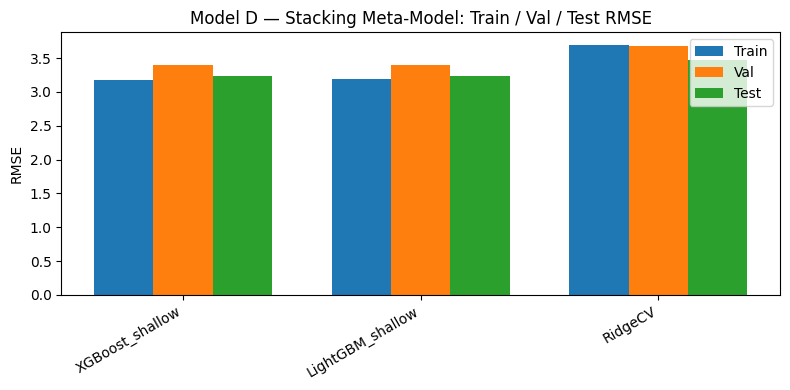

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(final_df))
w = 0.25
ax.bar(x - w, final_df["train_rmse"], w, label="Train")
ax.bar(x, final_df["val_rmse"], w, label="Val")
ax.bar(x + w, final_df["test_rmse"], w, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(final_df["model"], rotation=30, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Model D — Stacking Meta-Model: Train / Val / Test RMSE")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save Artifacts

In [18]:
for name in top3_names:
    params = reconstruct_d_params(name, r3_best_params[name])
    model = D_MODEL_CLASSES[name](**params)
    if name not in NAN_TOLERANT_D:
        model = wrap_imputer(model)
    model.fit(X_train_full, y_train_full)

    # Save predictions
    for split_name, X_s, y_s, id_s in [
        ("Training", X_train_full, y_train_full, id_train),
        ("Test", X_test, y_test, id_test),
    ]:
        out = id_s.copy()
        out["y_true"] = y_s.values
        out["y_pred"] = model.predict(X_s)
        fname = f"model_D_{name}_{split_name}.parquet"
        out.to_parquet(TRAINING_DIR / fname, index=False)
        print(f"  Saved {fname}")

    # Save pickle
    pkl_name = f"Model_D_{name}.pkl"
    with open(MODEL_DIR / pkl_name, "wb") as f:
        pickle.dump(model, f)
    print(f"  Saved {pkl_name}")

print("\nDone! All Model D artifacts saved.")

  Saved model_D_XGBoost_shallow_Training.parquet
  Saved model_D_XGBoost_shallow_Test.parquet
  Saved Model_D_XGBoost_shallow.pkl


  Saved model_D_LightGBM_shallow_Training.parquet
  Saved model_D_LightGBM_shallow_Test.parquet
  Saved Model_D_LightGBM_shallow.pkl
  Saved model_D_RidgeCV_Training.parquet
  Saved model_D_RidgeCV_Test.parquet
  Saved Model_D_RidgeCV.pkl

Done! All Model D artifacts saved.


## Summary

In [19]:
print("=" * 60)
print("MODEL D (STACKING) TRAINING COMPLETE")
print("=" * 60)
print(f"\nBest base models: A={best_A}, B={best_B}, C={best_C}")
print(f"Weighted average: A={best_weights[0]}, B={best_weights[1]}, C={best_weights[2]}, RMSE={wa_test_rmse:.4f}")
print(f"\nFinal meta-models:")
for _, row in final_df.iterrows():
    print(f"  {row['model']:20s}  test_rmse={row['test_rmse']:.4f}  gap={row['overfit_gap']:.4f}")

MODEL D (STACKING) TRAINING COMPLETE

Best base models: A=LightGBM_Deep, B=LightGBM_DART, C=RandomForest
Weighted average: A=0.4, B=0.0, C=0.6, RMSE=4.1335

Final meta-models:
  XGBoost_shallow       test_rmse=3.2340  gap=-0.1630
  LightGBM_shallow      test_rmse=3.2396  gap=-0.1606
  RidgeCV               test_rmse=3.4701  gap=-0.2100
